In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import torchvision.transforms as transforms

In [42]:
import sys, torch
print("python:", sys.executable)
print("cuda:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

python: /root/miniconda3/envs/msf/bin/python
cuda: True
gpu: NVIDIA GeForce RTX 4090


In [43]:
# 1. 多尺度特征提取模块
class MultiScaleFeatureExtractor(nn.Module):
    def __init__(self, in_channels=3):
        super(MultiScaleFeatureExtractor, self).__init__()
        # 128x128 卷积核
        self.conv_128 = nn.Conv2d(in_channels, 1, kernel_size=128, stride=1, padding=0)
        # 64x64 卷积核
        self.conv_64 = nn.Conv2d(in_channels, 1, kernel_size=64, stride=1, padding=0)
        # 32x32 卷积核
        self.conv_32 = nn.Conv2d(in_channels, 1, kernel_size=32, stride=1, padding=0)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: [B, 3, 1024, 1024]
        f_128 = self.relu(self.conv_128(x))  # [B, 1, 897, 897]
        f_64 = self.relu(self.conv_64(x))    # [B, 1, 961, 961]
        f_32 = self.relu(self.conv_32(x))    # [B, 1, 993, 993]
        return f_128, f_64, f_32


In [44]:
# 2. 多尺度特征金字塔模块（包含贝叶斯启发融合）
class MultiScaleFeaturePyramid(nn.Module):
    def __init__(self):
        super(MultiScaleFeaturePyramid, self).__init__()
        # 1x1卷积投影到统一通道数32
        self.proj_128 = nn.Conv2d(1, 32, kernel_size=1)
        self.proj_64 = nn.Conv2d(1, 32, kernel_size=1)
        self.proj_32 = nn.Conv2d(1, 32, kernel_size=1)

        # 下采样到128x128的可训练线性层
        self.downsample_128 = nn.Conv2d(32, 32, kernel_size=1)
        self.downsample_64 = nn.Conv2d(32, 32, kernel_size=1)
        self.downsample_32 = nn.Conv2d(32, 32, kernel_size=1)

        # 贝叶斯启发融合模块
        self.bayesian_fusion = nn.Conv2d(96, 32, kernel_size=1)

    def forward(self, f_128, f_64, f_32):
        # 投影到统一通道数
        p_128 = self.proj_128(f_128)  # [B, 32, 897, 897]
        p_64 = self.proj_64(f_64)     # [B, 32, 961, 961]
        p_32 = self.proj_32(f_32)     # [B, 32, 993, 993]

        # 下采样到128x128
        p_128_ds = F.interpolate(p_128, size=(128, 128), mode='bilinear')
        p_64_ds = F.interpolate(p_64, size=(128, 128), mode='bilinear')
        p_32_ds = F.interpolate(p_32, size=(128, 128), mode='bilinear')

        # 贝叶斯启发融合
        combined = torch.cat([p_128_ds, p_64_ds, p_32_ds], dim=1)  # [B, 96, 128, 128]
        p_4 = self.bayesian_fusion(combined)  # [B, 32, 128, 128]

        return p_128_ds, p_64_ds, p_32_ds, p_4


In [45]:
# 3. 病理扩散点推断模块
class PathologicalDiffusionInference(nn.Module):
    def __init__(self):
        super(PathologicalDiffusionInference, self).__init__()
        # 可训练权重系数alpha_i（每个金字塔层级一个）
        self.alpha_1 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)
        self.alpha_2 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)
        self.alpha_3 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)
        self.alpha_4 = nn.Parameter(torch.rand(1) * 0.2 + 0.9)

        # 1x1卷积用于特征变换
        self.f_transform = nn.Conv2d(32, 32, kernel_size=1)
        self.f_transform2 = nn.Conv2d(32, 32, kernel_size=1)

        # 输入投影
        self.input_proj = nn.Conv2d(3, 32, kernel_size=1)

    def compute_affinity(self, x, y):
        # x, y: [B, 32, 128, 128]
        B, C, H, W = x.shape
        x_flat = x.view(B, C, -1)  # [B, 32, 16384]
        y_flat = y.view(B, C, -1)  # [B, 32, 16384]

        # 计算亲和度矩阵
        affinity = torch.bmm(x_flat.transpose(1, 2), y_flat) / np.sqrt(8)  # [B, 16384, 16384]
        affinity = F.softmax(affinity, dim=-1)
        return affinity

    def forward(self, p_list, input_image):
        # p_list: [p1, p2, p3, p4]
        # input_image: [B, 3, 1024, 1024]

        # 处理输入图像
        input_ds = F.interpolate(input_image, size=(128, 128), mode='bilinear')
        y = self.input_proj(input_ds)  # [B, 32, 128, 128]

        refined_features = []
        for i, (p_i, alpha) in enumerate(zip(p_list, [self.alpha_1, self.alpha_2, self.alpha_3, self.alpha_4])):
            # 计算条件概率 P(X_i | Y_i)
            affinity = self.compute_affinity(p_i, y)
            B, HW, _ = affinity.shape
            rho_x = self.f_transform(p_i).view(B, 32, -1)  # [B, 32, 16384]
            p_cond = torch.bmm(affinity, rho_x.transpose(1, 2))  # [B, 16384, 32]
            p_cond = p_cond.transpose(1, 2).view(B, 32, 128, 128)  # [B, 32, 128, 128]

            # 特征变换 F(Y_i)
            f_y = F.relu(self.f_transform2(y))

            # 融合
            refined = alpha * p_cond * f_y
            refined_features.append(refined)

            # 更新y为当前 refined 特征
            y = refined

        return refined_features[-1]  # 返回最后一个精炼特征

In [46]:
# 4. 解码和分类层
class Decoder(nn.Module):
    def __init__(self, num_classes=2):
        super(Decoder, self).__init__()
        self.upsample = nn.ConvTranspose2d(
            32, num_classes, kernel_size=2, stride=2
        )

    def forward(self, x):
        return self.upsample(x)  # [B, 2, 256, 256]

In [47]:
# 5. CRF正则化损失
class CRFLoss(nn.Module):
    def __init__(self):
        super(CRFLoss, self).__init__()

    def forward(self, predictions, targets):
        # predictions: [B, 2, 1024, 1024] (softmax输出)
        # targets: [B, 1024, 1024] (0或1)

        B, C, H, W = predictions.shape
        predictions = predictions.view(B, C, -1)
        targets = targets.view(B, -1)

        # 一元势函数
        p_tumor = predictions[:, 1, :]  # 肿瘤概率
        p_bg = predictions[:, 0, :]     # 背景概率

        # CRF损失
        crf_loss = -torch.mean(targets * torch.log(p_tumor + 1e-8) +
                               (1 - targets) * torch.log(p_bg + 1e-8))
        return crf_loss

In [48]:
# 6. 完整的MSF-net模型
class MSFNet(nn.Module):
    def __init__(self, num_classes=2):
        super(MSFNet, self).__init__()
        self.feature_extractor = MultiScaleFeatureExtractor()
        self.feature_pyramid = MultiScaleFeaturePyramid()
        self.diffusion_inference = PathologicalDiffusionInference()
        self.decoder = Decoder(num_classes)

    def forward(self, x):
        # 多尺度特征提取
        f_128, f_64, f_32 = self.feature_extractor(x)

        # 多尺度特征金字塔
        p_128, p_64, p_32, p_4 = self.feature_pyramid(f_128, f_64, f_32)

        # 病理扩散点推断
        refined = self.diffusion_inference([p_32, p_64, p_128, p_4], x)

        # 解码和分类
        output = self.decoder(refined)

        return output

In [49]:
class BrainTumorDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.images = []
        self.masks = []

        # LGG 数据集结构：
        # data_dir/
        #   TCGA_xxx_xxxx/
        #     xxx_001.tif
        #     xxx_001_mask.tif
        #     ...

        for case in sorted(os.listdir(data_dir)):
            case_dir = os.path.join(data_dir, case)
            if not os.path.isdir(case_dir):
                continue

            for fname in sorted(os.listdir(case_dir)):
                if fname.endswith(".tif") and not fname.endswith("_mask.tif"):
                    img_path = os.path.join(case_dir, fname)
                    mask_path = img_path.replace(".tif", "_mask.tif")

                    if os.path.exists(mask_path):
                        self.images.append(img_path)
                        self.masks.append(mask_path)

        print(f"[BrainTumorDataset] Loaded {len(self.images)} samples")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")

        # 先用小尺寸，避免 OOM
        image = image.resize((256, 256), Image.BILINEAR)
        mask = mask.resize((256, 256), Image.NEAREST)

        image = np.array(image, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.int64)
        mask = (mask > 0).astype(np.int64)

        image = torch.from_numpy(image).permute(2, 0, 1)
        mask = torch.from_numpy(mask)

        return image, mask

In [50]:
# 8. 训练函数
def train_model(model, train_loader, val_loader, num_epochs=32, device='cuda', accum_steps=4):
    model = model.to(device)

    # 损失函数
    ce_loss = nn.CrossEntropyLoss()
    crf_loss = CRFLoss()

    # 优化器
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    os.makedirs('checkpoints', exist_ok=True)
    best_dice = -1.0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

        for step, (images, masks) in enumerate(train_loader):
            images = images.to(device)
            masks = masks.to(device)

            # 前向传播
            outputs = model(images)  # [B, 2, 1024, 1024]

            # 计算损失
            loss_ce = ce_loss(outputs, masks)
            loss_crf = crf_loss(torch.softmax(outputs, dim=1), masks)
            total_loss = loss_ce + loss_crf
            total_loss = total_loss / accum_steps

            # 反向传播
            total_loss.backward()

            if (step + 1) % accum_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

            train_loss += total_loss.item() * accum_steps

        avg_train_loss = train_loss / len(train_loader)

        # 验证
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)
                
                loss_ce = ce_loss(outputs, masks)
                loss_crf = crf_loss(torch.softmax(outputs, dim=1), masks)
                total_loss = loss_ce + loss_crf

                val_loss += total_loss.item()

                # 计算Dice系数
                preds = torch.argmax(outputs, dim=1)
                dice = compute_dice(preds, masks)
                iou = compute_iou(preds, masks)
                val_dice += dice
                val_iou  += iou

        avg_val_loss = val_loss / len(val_loader)
        avg_val_dice = val_dice / len(val_loader)
        avg_val_iou  = val_iou  / len(val_loader)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss/len(train_loader):.4f}')
        print(f'Val Loss:   {avg_val_loss:.4f}')
        print(f'Val Dice:   {avg_val_dice:.4f}')
        print(f'Val IoU:    {avg_val_iou:.4f}')
        print('-' * 50)

# checkpoint 保存
        torch.save(model.state_dict(), f'checkpoints/epoch_{epoch+1}.pth')

        if avg_val_dice > best_dice:
            best_dice = avg_val_dice
            torch.save(model.state_dict(), 'checkpoints/best_model.pth')
            print(f'Best model saved at epoch {epoch+1} (Dice={best_dice:.4f})')

In [51]:
# 9. 计算Dice系数的函数
def compute_dice(preds, targets):
    smooth = 1e-6
    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    dice = (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)
    return dice.item()

In [52]:
#10.计算IoU分数
def compute_iou(preds, targets):
    smooth = 1e-6
    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds & targets).sum()
    union = preds.sum() + targets.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.item()

In [53]:
# 11. 主函数
def main():
    # 设置设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    # 数据路径
    data_dir = '/root/autodl-tmp/data/lgg-mri-segmentation/3m'

    # 创建完整数据集
    full_dataset = BrainTumorDataset(data_dir)
    print(f'Total samples: {len(full_dataset)}')
    
    # 划分训练集和验证集（slice 级随机划分）
    dataset_size = len(full_dataset)
    val_size = int(0.2 * dataset_size)
    train_size = dataset_size - val_size

    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset,
        [train_size, val_size]
    )

    # 创建数据加载器
    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)

    # 创建模型
    model = MSFNet(num_classes=2)
    print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

    # 训练模型
    train_model(model, train_loader, val_loader, num_epochs=32, device=device)

    # 保存模型
    torch.save(model.state_dict(), 'MSF_net_model.pth')
    print('Model saved to MSF_net_model.pth')

if __name__ == '__main__':
    main()

Using device: cuda
[BrainTumorDataset] Loaded 3929 samples
Total samples: 3929
Model parameters: 73,481
Epoch 1/32:
Train Loss: 0.2728
Val Loss:   0.1212
Val Dice:   0.6040
Val IoU:    0.6034
--------------------------------------------------
Best model saved at epoch 1 (Dice=0.6040)
Epoch 2/32:
Train Loss: 0.1169
Val Loss:   0.1274
Val Dice:   0.4673
Val IoU:    0.4443
--------------------------------------------------
Epoch 3/32:
Train Loss: 0.1002
Val Loss:   0.0846
Val Dice:   0.5606
Val IoU:    0.5522
--------------------------------------------------


KeyboardInterrupt: 

In [56]:
import sys
!{sys.executable} -m pip install matplotlib

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 15.0 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 15.1 MB/s  0:00:00 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_one_sample(model, dataset, idx=0, device='cuda', save_path=None):
    model.eval()
    model.to(device)

    # dataset[idx] -> (image, mask)
    image, mask = dataset[idx]              # image: [3,H,W], mask: [H,W]
    image = image.unsqueeze(0).to(device)   # [1,3,H,W]
    mask_np = mask.numpy()                  # [H,W]

    with torch.no_grad():
        logits = model(image)               # [1,2,H,W]
        
        prob = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()
        print("tumor prob min/max/mean:",
            prob.min(), prob.max(), prob.mean())
        
        pred = torch.argmax(logits, dim=1)[0].cpu().numpy().astype(np.uint8)  # [H,W]

    # 原图展示用（把 [3,H,W] 转成 [H,W,3]）
    img_np = image[0].cpu().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0.0, 1.0)

    # overlay：红色叠加预测区域
    overlay = img_np.copy()
    overlay[pred == 1] = overlay[pred == 1] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.title("Image")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("GT Mask")
    plt.imshow(mask_np, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Pred Mask")
    plt.imshow(pred, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Overlay (Pred)")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200)
        print(f"Saved to: {save_path}")

    plt.show()

[BrainTumorDataset] Loaded 3929 samples
tumor prob min/max/mean: 8.706031e-09 0.16934007 0.0034782526
Saved to: pred_vis.png


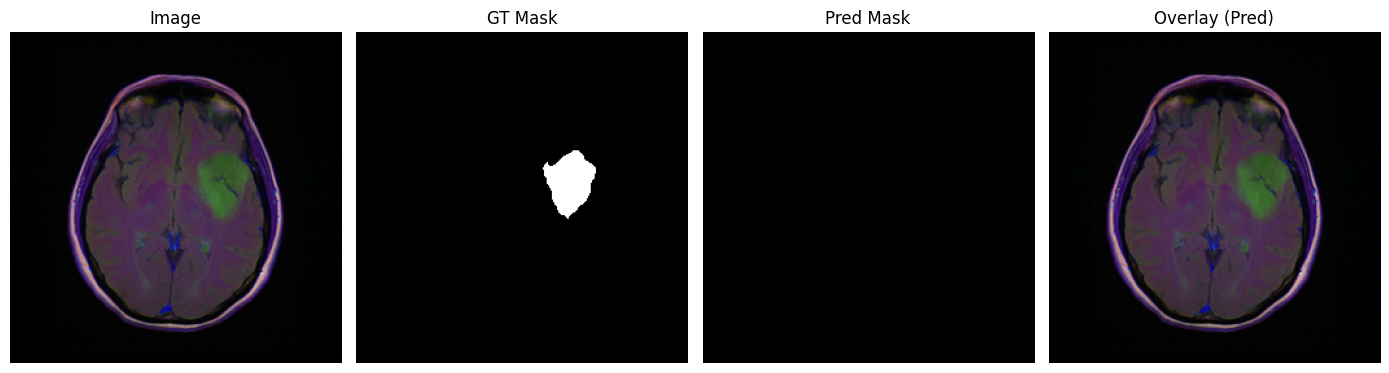

In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 重新构建 dataset
data_dir = '/root/autodl-tmp/data/lgg-mri-segmentation/3m'
full_dataset = BrainTumorDataset(data_dir)

dataset_size = len(full_dataset)
val_size = int(0.2 * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size]
)

# 加载模型
model = MSFNet(num_classes=2)
model.load_state_dict(torch.load('checkpoints/best_model.pth', map_location=device))
model.to(device)
model.eval()

# 可视化
visualize_one_sample(model, val_dataset, idx=0, device=device, save_path='pred_vis.png')